In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
img = cv2.imread('bertalmio_im1.png')
px.imshow(img)


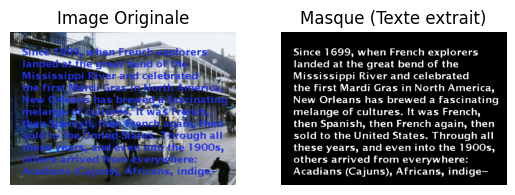

True

In [3]:
import cv2
import numpy as np

# 1. Charger l'image
image = cv2.imread('bertalmio_im1.png')
if image is None:
    print("Image introuvable !")
    exit()

# 2. Définir la couleur cible (Attention: OpenCV utilise le format BGR)
# Le texte est un rouge pur ou presque : [Bleu=0, Vert=0, Rouge=255]
target_color = np.array([30, 35, 230]) # Un rouge un peu ajusté pour ton image

# 3. Calculer la distance de chaque pixel par rapport à la cible
# On utilise float32 pour éviter les erreurs d'overflow (dépassement de 255)
diff = image.astype(np.float32) - target_color
dist = np.sqrt(np.sum(diff**2, axis=2))

# 4. Créer le masque : si distance < seuil, alors c'est du texte (255), sinon fond (0)
# Ajuste le seuil (threshold) selon les résultats (entre 50 et 100 en général)
threshold = 50
mask = np.zeros(dist.shape, dtype=np.uint8)
mask[dist < threshold] = 255

# 5. Nettoyage rapide (pour enlever les petits pixels isolés)
kernel = np.ones((2,2), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

plt.subplot(1, 2, 1)
plt.title("Image Originale")
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Masque (Texte extrait)")
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.show()

    # Sauvegarde du masque pour ton inpainting
cv2.imwrite('mask_result.png', mask)

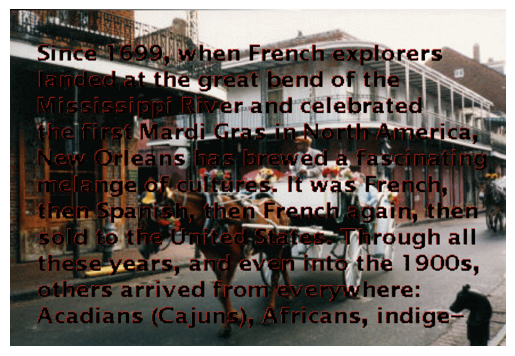

In [4]:
# 1. On inverse le masque (le "1 - mask")
mask_inv = cv2.bitwise_not(mask)

# 2. On applique le ET logique bit à bit
# Tout ce qui est blanc (255) dans mask_inv reste, le reste devient noir (0)
img_result = cv2.bitwise_and(image, image, mask=mask_inv)

# Affichage direct
plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [5]:
img1 = cv2.imread('data/image1.png')
mask1 = cv2.imread('data/mask1.png',0)
mask1 = 255 - mask1
img_u1 = cv2.bitwise_and(img1, img1, mask=mask1)
img_u1 = cv2.cvtColor(img_u1, cv2.COLOR_BGR2Luv)
px.imshow(img_u1)

In [6]:
gy , gx , couleurs= np.gradient(img_u1)
lapy ,poubelle , couleury = np.gradient(gy)
poubelle , lapx,couleurx = np.gradient(gx)
px.imshow(lapy)